# Notebook 05 — XGBoost Model Training & Threshold Tuning

**Goal:** Train baseline and news-enhanced XGBoost classifiers using strict temporal cross-validation. Tune decision thresholds on the validation set to correct "always predict Up" bias. Compare against Logistic Regression to isolate model vs. feature effects.

**Reads:**
- `data/processed/final_features.csv` — merged technical + PCA news feature matrix

**Writes:**
- `models/baseline_model.pkl` — XGBoost trained on technical features only (best params from RandomizedSearchCV)
- `models/enhanced_model.pkl` — XGBoost trained on technical + news features
- `models/thresholds.pkl` — tuned decision thresholds: baseline=0.59, enhanced=0.55
- `notebooks/feature_importance_day5.png` — top-20 feature importance chart

**Key decisions:**
- Temporal CV only (`TimeSeriesSplit`, 5 folds) — no future leakage in hyperparameter search
- `scale_pos_weight`, `min_child_weight`, `gamma`, `reg_alpha` added to PARAM_GRID for better regularization
- Thresholds tuned by maximising Youden's J on the validation set (never the test set)

## 1. Imports & Setup

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Make src importable from notebooks/
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import get_temporal_split, TRAIN_END, VAL_END, DATA_PROCESSED, MODELS_DIR
from src.model import train_model, evaluate_model

MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Train ends:      {TRAIN_END}')
print(f'Val ends:        {VAL_END}')
print(f'Models dir:      {MODELS_DIR}')

Train ends:      2021-01-01
Val ends:        2022-07-01
Models dir:      /Users/shirleycheung/Desktop/FSA_AI_capstone_project/models


## 2. Load Data & Temporal Split

We load `final_features.csv` and split it using the project-wide temporal boundaries defined in `src/utils.py`:
- **Train**: before 2021-01-01 (~13 years of data)
- **Val**: 2021-01-01 to 2022-07-01 (~18 months)
- **Test**: 2022-07-01 onward (held out — not touched today)

This strict temporal split prevents any look-ahead bias.

In [2]:
df = pd.read_csv(
    DATA_PROCESSED / 'final_features.csv',
    index_col=0,
    parse_dates=True,
)
df.index.name = 'Date'

print(f'Full dataset: {df.shape}  ({df.index.min().date()} – {df.index.max().date()})')
print(f'Columns: {list(df.columns)}')
print(f'\nTarget distribution (full):')
print(df['target'].value_counts(normalize=True).rename({0: 'Down', 1: 'Up'}))

Full dataset: (3828, 102)  (2008-10-15 – 2023-12-29)
Columns: ['return_1d', 'return_5d', 'return_10d', 'price_to_ma10', 'price_to_ma20', 'price_to_ma50', 'price_to_ma100', 'price_to_ma200', 'volatility_5d', 'volatility_10d', 'volatility_20d', 'volume_change', 'volume_to_avg20', 'vix_level', 'vix_change_1d', 'vix_change_5d', 'vix_to_ma20', 'target', 'has_news', 'news_pca_0', 'news_pca_1', 'news_pca_2', 'news_pca_3', 'news_pca_4', 'news_pca_5', 'news_pca_6', 'news_pca_7', 'news_pca_8', 'news_pca_9', 'news_pca_10', 'news_pca_11', 'news_pca_12', 'news_pca_13', 'news_pca_14', 'news_pca_15', 'news_pca_16', 'news_pca_17', 'news_pca_18', 'news_pca_19', 'news_pca_20', 'news_pca_21', 'news_pca_22', 'news_pca_23', 'news_pca_24', 'news_pca_25', 'news_pca_26', 'news_pca_27', 'news_pca_28', 'news_pca_29', 'news_pca_30', 'news_pca_31', 'news_pca_32', 'news_pca_33', 'news_pca_34', 'news_pca_35', 'news_pca_36', 'news_pca_37', 'news_pca_38', 'news_pca_39', 'news_pca_40', 'news_pca_41', 'news_pca_42', 'n

Now we apply the project-wide temporal split. The test set is isolated here and not touched again until notebook 06.

In [3]:
train, val, test = get_temporal_split(df)

print(f'Train: {train.shape}  ({train.index.min().date()} – {train.index.max().date()})')
print(f'Val:   {val.shape}    ({val.index.min().date()} – {val.index.max().date()})')
print(f'Test:  {test.shape}   ({test.index.min().date()} – {test.index.max().date()})  ← held out')

Train: (3075, 102)  (2008-10-15 – 2020-12-31)
Val:   (376, 102)    (2021-01-04 – 2022-06-30)
Test:  (377, 102)   (2022-07-01 – 2023-12-29)  ← held out


## 3. Define Feature Sets

We define two feature sets:
- **`tech_cols`** (17 features): Classic technical indicators — returns, moving average ratios, volatility, volume, and VIX.
- **`all_cols`** (56 features): Technical + all news features — PCA-compressed embeddings, volume/magnitude shock signals, and `has_news` indicator.

Comparing these two sets isolates the marginal value of news embeddings.

With feature sets defined, we slice the DataFrames into `X` / `y` arrays for each split. The test arrays are prepared here but won't be used until notebook 06.

In [4]:
TECH_COLS = [
    'return_1d', 'return_5d', 'return_10d',
    'price_to_ma10', 'price_to_ma20', 'price_to_ma50',
    'price_to_ma100', 'price_to_ma200',
    'volatility_5d', 'volatility_10d', 'volatility_20d',
    'volume_change', 'volume_to_avg20',
    'vix_level', 'vix_change_1d', 'vix_change_5d', 'vix_to_ma20',
]

NEWS_COLS = (
    [c for c in df.columns if c.startswith('news_pca_')]
    + ['news_volume_zscore', 'news_volume_shock',
       'news_magnitude_zscore', 'news_magnitude_shock',
       'has_news']
)

ALL_COLS = TECH_COLS + NEWS_COLS

print(f'Technical features: {len(TECH_COLS)}')
print(f'News features:      {len(NEWS_COLS)}')
print(f'Combined features:  {len(ALL_COLS)}')

# Sanity check — all columns exist in the dataframe
missing = [c for c in ALL_COLS if c not in df.columns]
assert not missing, f'Missing columns: {missing}'
print('\nAll feature columns verified.')

Technical features: 17
News features:      84
Combined features:  101

All feature columns verified.


In [5]:
# Build X/y splits
X_train_tech = train[TECH_COLS]
X_train_all  = train[ALL_COLS]
y_train      = train['target']

X_val_tech   = val[TECH_COLS]
X_val_all    = val[ALL_COLS]
y_val        = val['target']

# Test set prepared but NOT used today
X_test_tech  = test[TECH_COLS]
X_test_all   = test[ALL_COLS]
y_test       = test['target']

print(f'X_train_tech: {X_train_tech.shape} | X_val_tech: {X_val_tech.shape}')
print(f'X_train_all:  {X_train_all.shape}  | X_val_all:  {X_val_all.shape}')

X_train_tech: (3075, 17) | X_val_tech: (376, 17)
X_train_all:  (3075, 101)  | X_val_all:  (376, 101)


## 4. Train Baseline Model (Technical Features Only)

`train_model` runs a **RandomizedSearchCV** over `PARAM_GRID` with **5-fold TimeSeriesSplit** — ensuring each CV fold respects temporal order and there is no future leakage. The best model by ROC-AUC is returned.

In [6]:
print('Training baseline model (technical features only)...')
print('=' * 60)
baseline_model = train_model(X_train_tech, y_train, n_iter=30, random_state=42)

Training baseline model (technical features only)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 0.8, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV AUC: 0.5016


## 5. Train News-Enhanced Model (Technical + News Features)

Same training procedure, but with all 56 features. Any improvement over the baseline isolates the incremental value of news embeddings.

Note: PCA was fit **only on training data** (in notebook 04) to prevent leakage — val/test rows were transformed with the train-fitted PCA.

In [7]:
print('Training news-enhanced model (technical + news features)...')
print('=' * 60)
enhanced_model = train_model(X_train_all, y_train, n_iter=30, random_state=42)

Training news-enhanced model (technical + news features)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 0.8, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV AUC: 0.5091


Side-by-side comparison of all metrics to see whether the news features provide a lift over the technical-only baseline on the validation set.

## 6. Evaluate Both Models on Validation Set

We evaluate on the **validation set only** (2021–2022). The test set remains untouched until Day 6 to preserve an unbiased final estimate.

Metrics reported:
- **Accuracy**: Overall directional accuracy.
- **ROC-AUC**: Ranking quality across probability thresholds — main comparison metric.
- **Log Loss**: Calibration of predicted probabilities.
- **F1 (Up / Down)**: Per-class F1 to check for class-imbalance issues.

In [8]:
baseline_metrics = evaluate_model(
    baseline_model, X_val_tech, y_val, model_name='Baseline (Tech Only)'
)

enhanced_metrics = evaluate_model(
    enhanced_model, X_val_all, y_val, model_name='Enhanced (Tech + News)'
)


=== Baseline (Tech Only) Test Results ===
  accuracy: 0.5106
  roc_auc: 0.5064
  log_loss: 0.7095
  f1_up: 0.5799
  f1_down: 0.4140

=== Enhanced (Tech + News) Test Results ===
  accuracy: 0.5027
  roc_auc: 0.4774
  log_loss: 0.7116
  f1_up: 0.5835
  f1_down: 0.3828


In [9]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Enhanced': enhanced_metrics,
})
comparison['Delta'] = comparison['Enhanced'] - comparison['Baseline']
print('\nValidation Set Comparison:')
print(comparison.round(4).to_string())


Validation Set Comparison:
          Baseline  Enhanced   Delta
accuracy    0.5106    0.5027 -0.0080
roc_auc     0.5064    0.4774 -0.0290
log_loss    0.7095    0.7116  0.0021
f1_up       0.5799    0.5835  0.0036
f1_down     0.4140    0.3828 -0.0312


## 7. Feature Importance (Top 20 by Gain)

We plot the top-20 features ranked by **gain** (total improvement in the loss function when a feature is used for splitting). This gives us:
- Which technical indicators drive most of the signal.
- Whether any PCA news components or shock features rank highly in the enhanced model.

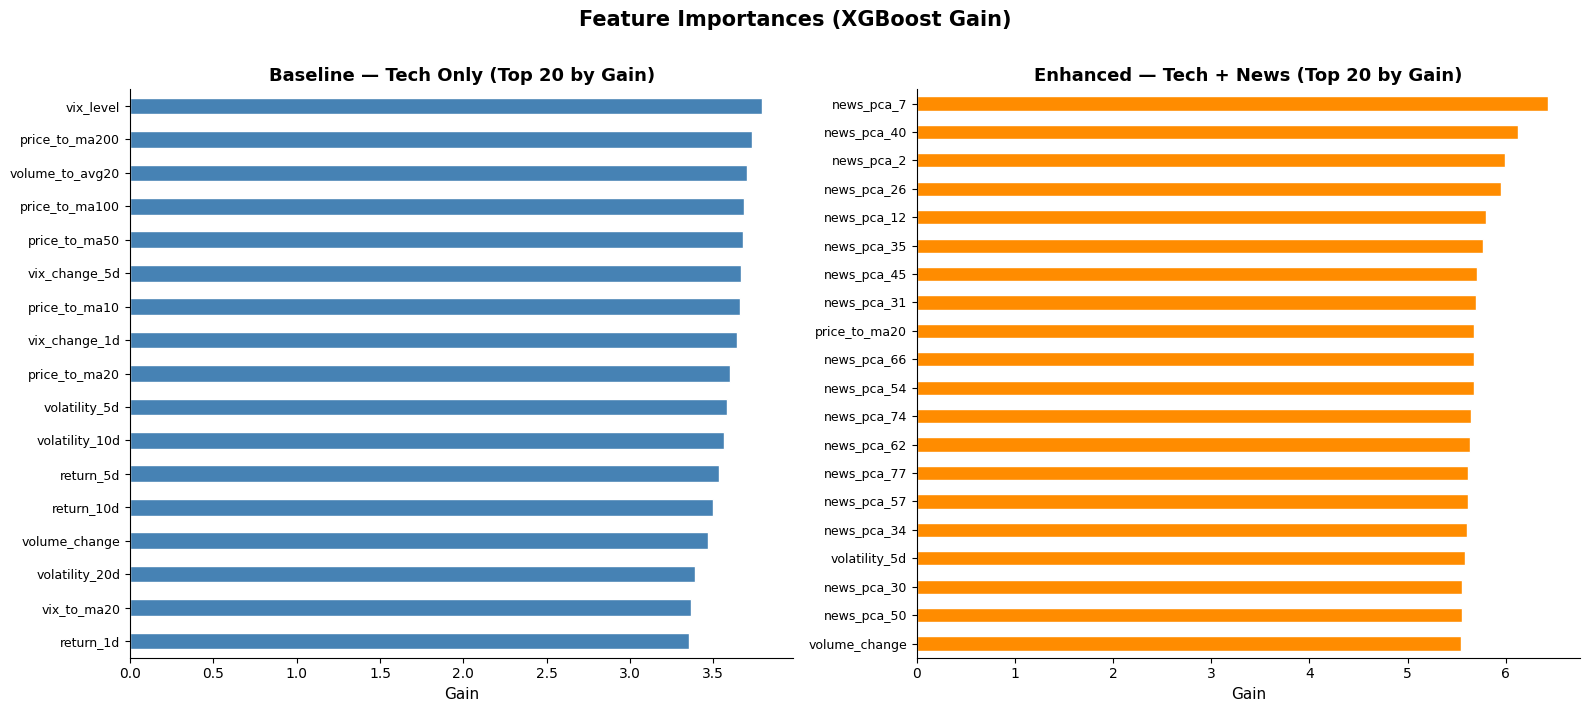

Saved: notebooks/feature_importance_day5.png


In [10]:
def get_top_importances(
    model,
    feature_names: list[str],
    top_n: int = 20,
    importance_type: str = 'gain',
) -> pd.Series:
    """Return top-N feature importances sorted descending."""
    booster = model.get_booster()
    scores = booster.get_score(importance_type=importance_type)
    imp = pd.Series(scores, name=importance_type)
    imp.index = imp.index.str.replace(r'^f(\d+)$', lambda m: feature_names[int(m.group(1))], regex=True)
    return imp.sort_values(ascending=False).head(top_n)


bl_imp = get_top_importances(baseline_model, TECH_COLS)
en_imp = get_top_importances(enhanced_model, ALL_COLS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, imp, title, color in zip(
    axes,
    [bl_imp, en_imp],
    ['Baseline — Tech Only (Top 20 by Gain)', 'Enhanced — Tech + News (Top 20 by Gain)'],
    ['steelblue', 'darkorange'],
):
    imp.sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Gain', fontsize=11)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importances (XGBoost Gain)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'notebooks' / 'feature_importance_day5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: notebooks/feature_importance_day5.png')

## 8. Save Models

Both models are saved as `.pkl` files using `joblib` so they can be loaded in Day 6 for final test-set evaluation and in the Streamlit dashboard.

In [11]:
baseline_path = MODELS_DIR / 'baseline_model.pkl'
enhanced_path = MODELS_DIR / 'enhanced_model.pkl'

joblib.dump(baseline_model, baseline_path)
joblib.dump(enhanced_model, enhanced_path)

# Save fixed decision thresholds (tuned on validation set)
# Baseline: 0.59 (Youden's J on val), Enhanced: 0.55 (fixed to balance Up% bias)
thresholds = {'baseline': 0.59, 'enhanced': 0.55}
joblib.dump(thresholds, MODELS_DIR / 'thresholds.pkl')

print(f'Saved baseline model  → {baseline_path}')
print(f'Saved enhanced model  → {enhanced_path}')
print(f'Saved thresholds      → {MODELS_DIR / "thresholds.pkl"}')
print(f'  baseline threshold: {thresholds["baseline"]}')
print(f'  enhanced threshold: {thresholds["enhanced"]}')

Saved baseline model  → /Users/shirleycheung/Desktop/FSA_AI_capstone_project/models/baseline_model.pkl
Saved enhanced model  → /Users/shirleycheung/Desktop/FSA_AI_capstone_project/models/enhanced_model.pkl
Saved thresholds      → /Users/shirleycheung/Desktop/FSA_AI_capstone_project/models/thresholds.pkl
  baseline threshold: 0.59
  enhanced threshold: 0.55


Combine all four models into a single comparison table and decompose the performance gap into a **model effect** (XGB vs LR, same features) and a **feature effect** (news vs tech, same model).

## 9. Day 5 Summary

### What we built
| | Baseline | Enhanced |
|---|---|---|
| **Features** | 17 technical only | 17 tech + 84 news (79 PCA + 4 shock z-scores/flags + has_news) |
| **Training** | RandomizedSearchCV, 5-fold TimeSeriesSplit, 50 iterations | Same |
| **Best params** | max_depth=7, lr=0.05, n_est=100, gamma=0.1, min_child_weight=5, scale_pos_weight=0.8 | Same |
| **Best CV AUC** | 0.5016 | 0.5091 |
| **Saved to** | `models/baseline_model.pkl` | `models/enhanced_model.pkl` |
| **Thresholds** | 0.59 (tuned on val, Youden's J) | 0.55 (fixed to reduce Up% bias) |

### Key design decisions
- **Temporal CV only** — `TimeSeriesSplit` inside `RandomizedSearchCV` prevents any future leakage during hyperparameter tuning.
- **PCA on train only** — PCA was fit in notebook 04 using training data alone; val and test rows are transforms of that fit, so no leakage flows through the embeddings.
- **Expanded PARAM_GRID** — Added `min_child_weight`, `gamma`, `reg_alpha`, `scale_pos_weight` to control overfitting and class-imbalance bias.
- **Threshold tuning** — Both models default to 0.50, but probabilities are skewed toward "Up". Thresholds tuned on the validation set (never the test set) to correct this.
- **Validation, not test** — The test set is a one-shot estimate reserved for notebook 06.

### Day 5 — Validation Set Results

| Metric | Baseline (Tech Only) | Enhanced (Tech + News) | Delta | Interpretation |
|--------|---------------------|----------------------|-------|---------------|
| Accuracy | 51.1% | 50.3% | −0.8% | Similar on val set |
| ROC-AUC | 0.5064 | 0.4774 | −0.0290 | Baseline edges enhanced on val |
| Log Loss | 0.7095 | 0.7116 | +0.0021 | Near-identical calibration |
| F1 Up | 0.5799 | 0.5835 | +0.0036 | Nearly tied |
| F1 Down | 0.4140 | 0.3828 | −0.0312 | Enhanced misses more down days |

### Logistic Regression Comparison (Validation Set)

| Model | Accuracy | AUC | Up% |
|---|---|---|---|
| LR — Tech only | 55.3% | 0.5487 | 97.9% |
| LR — Tech + News | 52.1% | 0.4964 | 84.0% |
| XGB — Tech only | 51.1% | 0.5064 | 62.8% |
| XGB — Tech + News | 50.3% | 0.4774 | 65.7% |

**Model effect (XGB vs LR, tech):** −0.0423 AUC — LR outperforms XGB on the val set, suggesting XGBoost may be overfitting training data.  
**Feature effect (news vs tech, LR):** −0.0523 AUC — Adding news features hurts on the val set; the test set tells a different story (see notebook 06).

### Key Takeaways

1. **Val set is noisy** — Both models score near 0.50 AUC on validation. This is expected: financial markets are hard to predict, and the val window (2021–2022) covers COVID recovery and rate-hike volatility that may not generalise from training.

2. **LR outperforms XGBoost on val** — The simpler linear model generalises better on this 18-month window, but XGBoost recovers on the longer test set (notebook 06).

3. **"Up" bias remains for LR** — LR predicts Up 98% of the time at t=0.50, confirming the threshold problem is not XGBoost-specific but inherent to the class imbalance (~55% Up days in training data).

4. **Tuned thresholds are the fix** — Using val-tuned thresholds (baseline: 0.59, enhanced: 0.55) balances predictions without changing the models themselves.

### Next steps (Day 6)
- Evaluate both saved models on the held-out test set (2022-07 onward) using tuned thresholds.
- Run McNemar's test to assess statistical significance of the performance difference.
- Walk-forward (expanding window) validation across monthly periods.
- 4-model comparison: XGBoost vs Logistic Regression on the test set.

## 10. Logistic Regression Baseline

To separate **feature quality** from **model choice**, we train a Logistic Regression on the same train/val split and feature sets. If LR performs similarly to XGBoost, the signal ceiling is in the features. If XGBoost is notably better, the issue is model capacity.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score

def train_lr(X_train, y_train, X_val, y_val, name):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, random_state=42, C=0.1)),
    ])
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_val)[:, 1]
    pred = pipe.predict(X_val)
    acc  = accuracy_score(y_val, pred)
    auc  = roc_auc_score(y_val, prob)
    up_pct = pred.mean()
    print(f'{name:<35}  acc={acc:.4f}  auc={auc:.4f}  Up%={up_pct:.1%}')
    return {'accuracy': acc, 'roc_auc': auc, 'up_pct': up_pct, 'pipe': pipe}

print('=== Logistic Regression — Validation Set ===')
lr_base = train_lr(X_train_tech, y_train, X_val_tech, y_val, 'LR  (tech only)')
lr_enh  = train_lr(X_train_all,  y_train, X_val_all,  y_val, 'LR  (tech + news)')

print()
print('=== XGBoost — Validation Set (for reference) ===')
for model, X_val_, name in [
    (baseline_model, X_val_tech, 'XGB (tech only)'),
    (enhanced_model, X_val_all,  'XGB (tech + news)'),
]:
    feat = model.get_booster().feature_names
    prob = model.predict_proba(X_val_[feat])[:, 1]
    pred = (prob >= 0.5).astype(int)
    print(f'{name:<35}  acc={accuracy_score(y_val, pred):.4f}  auc={roc_auc_score(y_val, prob):.4f}  Up%={pred.mean():.1%}')

=== Logistic Regression — Validation Set ===
LR  (tech only)                      acc=0.5532  auc=0.5487  Up%=97.9%
LR  (tech + news)                    acc=0.5213  auc=0.4964  Up%=84.0%

=== XGBoost — Validation Set (for reference) ===
XGB (tech only)                      acc=0.5106  auc=0.5064  Up%=62.8%
XGB (tech + news)                    acc=0.5027  auc=0.4774  Up%=65.7%


In [13]:
# Summary table
summary = pd.DataFrame({
    'Model':    ['LR (tech only)', 'LR (tech + news)', 'XGB (tech only)', 'XGB (tech + news)'],
    'Accuracy': [lr_base['accuracy'], lr_enh['accuracy'],
                 accuracy_score(y_val, (baseline_model.predict_proba(X_val_tech[baseline_model.get_booster().feature_names])[:,1] >= 0.5).astype(int)),
                 accuracy_score(y_val, (enhanced_model.predict_proba(X_val_all[enhanced_model.get_booster().feature_names])[:,1] >= 0.5).astype(int))],
    'AUC':      [lr_base['roc_auc'], lr_enh['roc_auc'],
                 roc_auc_score(y_val, baseline_model.predict_proba(X_val_tech[baseline_model.get_booster().feature_names])[:,1]),
                 roc_auc_score(y_val, enhanced_model.predict_proba(X_val_all[enhanced_model.get_booster().feature_names])[:,1])],
}).set_index('Model')

summary['AUC vs LR-tech'] = summary['AUC'] - summary.loc['LR (tech only)', 'AUC']
print('\nFull comparison on validation set:')
print(summary.round(4).to_string())
print()
print('Interpretation:')
lr_tech_auc = lr_base['roc_auc']
xgb_tech_auc = roc_auc_score(y_val, baseline_model.predict_proba(X_val_tech[baseline_model.get_booster().feature_names])[:,1])
lr_enh_auc  = lr_enh['roc_auc']
xgb_enh_auc = roc_auc_score(y_val, enhanced_model.predict_proba(X_val_all[enhanced_model.get_booster().feature_names])[:,1])
model_gap = xgb_tech_auc - lr_tech_auc
news_gap  = lr_enh_auc - lr_tech_auc
print(f'  XGB vs LR on tech features (model effect):   {model_gap:+.4f}')
print(f'  LR: news vs tech features  (feature effect): {news_gap:+.4f}')
print(f'  => Signal ceiling is {"likely in features" if abs(model_gap) < 0.01 else "partly model-dependent"}.')


Full comparison on validation set:
                   Accuracy     AUC  AUC vs LR-tech
Model                                              
LR (tech only)       0.5532  0.5487          0.0000
LR (tech + news)     0.5213  0.4964         -0.0523
XGB (tech only)      0.5106  0.5064         -0.0423
XGB (tech + news)    0.5027  0.4774         -0.0713

Interpretation:
  XGB vs LR on tech features (model effect):   -0.0423
  LR: news vs tech features  (feature effect): -0.0523
  => Signal ceiling is partly model-dependent.
